In [95]:
import torch
import torch.nn as nn
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.nn import MSELoss

# Model

## Encoder

In [96]:
class Encoder(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.hidden_dim = int(abs(self.in_dim - self.out_dim) / 2)
        self.net = nn.Sequential(
            nn.Linear(self.in_dim, self.hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(self.hidden_dim, self.out_dim)
        )

    def forward(self, X: torch.Tensor):
        return self.net(X)

## Decoder

In [97]:
class Decoder(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.hidden_dim = int(abs(self.in_dim - self.out_dim) / 2)
        self.net = nn.Sequential(
            nn.Linear(self.in_dim, self.hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(self.hidden_dim, self.out_dim)
        )

    def forward(self, X: torch.Tensor):
        return self.net(X)

## Autoencoder

In [98]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim: int, code_dim: int, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.in_dim = in_dim
        self.code_dim = code_dim
        self.net = nn.Sequential(
            Encoder(self.in_dim, self.code_dim),
            Decoder(self.code_dim, self.in_dim)
        )

    def forward(self, X: torch.Tensor):
        return self.net(X)

# Configuration

In [99]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
N_EPOCHS = 10
BATCH_SIZE = 128
INPUT_DIM = 28 * 28
CODE_DIM = 10
LEARNING_RATE = 0.001

print(f'Device set to: {DEVICE}')

Device set to: cuda:0


# Data Load

In [100]:
train_data = FashionMNIST(
    root='train_data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = FashionMNIST(
    root='test_data',
    train=False,
    download=True,
    transform=ToTensor()
)

data_loader_train = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

data_loader_test = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

## Plot Data Samples

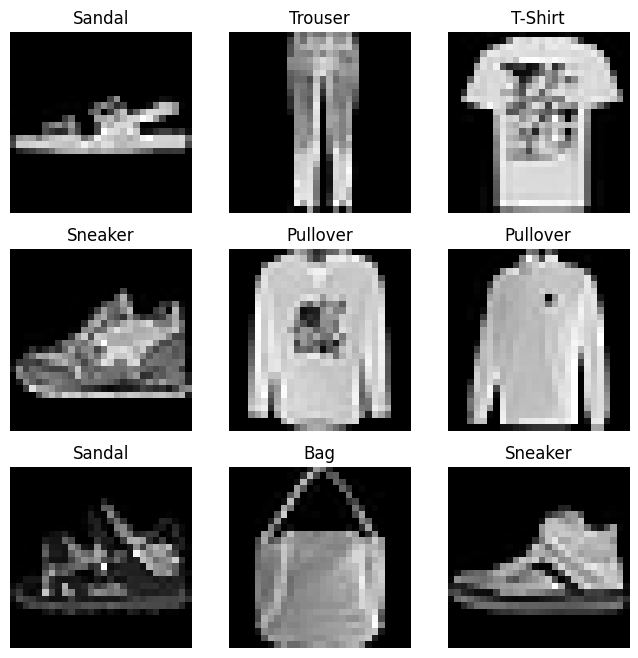

In [101]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Training

In [102]:
model = Autoencoder(
    in_dim=INPUT_DIM,
    code_dim=CODE_DIM
).to(DEVICE)

opt = Adam(
    params=model.parameters(),
    lr=LEARNING_RATE
)

loss_function = MSELoss().to(DEVICE)

In [103]:
for epoch in range(N_EPOCHS):
    print(f'Epoch {epoch}:')
    for x, _ in data_loader_train:
        opt.zero_grad()

        x = x.to(DEVICE)
        pred = model(x)
        loss = loss_function(pred, x)
        loss.backward()

        opt.step()
    print('-' * 20)

Epoch 0:


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x387)

# Test